<a href="https://colab.research.google.com/github/MaggieHDez/ClassFiles/blob/RN/clasificacionAlzheimer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
marcopinamonti_alzheimer_mri_4_classes_dataset_path = kagglehub.dataset_download('marcopinamonti/alzheimer-mri-4-classes-dataset')

print('Data source import complete.')


100%|██████████| 34.1M/34.1M [00:00<00:00, 60.2MB/s]

Extracting files...


Data source import complete.


In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.mixed_precision import set_global_policy
import math
import matplotlib.pyplot as plt
import pandas as pd
import os
from sklearn.model_selection import train_test_split
import numpy as np
import kagglehub
import time
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

# 🔧 Configurar GPU para asignar memoria de forma dinámica
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("Memoria de GPU configurada para crecimiento dinámico.")
    except RuntimeError as e:
        print("Error al configurar memoria de GPU:", e)

set_global_policy('mixed_float16')#added mix-precision here its faster
print("Downloading dataset...")
# Ubicación de la base de datos en Kaggle
data_dir = kagglehub.dataset_download("marcopinamonti/alzheimer-mri-4-classes-dataset")
print(f"Dataset downloaded to: {data_dir}")
#label mapping
diagnosis_mapping = {
    0: 'MildDemented',
    1: 'ModerateDemented',
    2: 'NonDemented',
    3: 'VeryMildDemented',
}
dir_to_code = {
    'MildDemented': 0,
    'ModerateDemented': 1,
    'NonDemented': 2,
    'VeryMildDemented': 3,
}
def get_image_paths_and_labels():
    image_paths=[]
    labels=[]

    images_dir=os.path.join(data_dir, 'Alzheimer_MRI_4_classes_dataset')

    for class_name, class_code in dir_to_code.items():
        class_dir=os.path.join(images_dir, class_name)
        if os.path.exists(class_dir):
            jpg_files=[f for f in os.listdir(class_dir) if f.lower().endswith('.jpg')]
            for file in jpg_files:
                image_paths.append(os.path.join(class_dir, file))
                labels.append(class_code)

    return np.array(image_paths), np.array(labels)


print("\nCollecting image paths and labels...")
image_paths, labels = get_image_paths_and_labels()
unique, counts = np.unique(labels, return_counts=True)
print("\nClass distribution:")
for label, count in zip(unique, counts):
    print(f"Class {diagnosis_mapping[label]}: {count} images")


#train & validation
train_paths,val_paths,train_labels,val_labels = train_test_split(
    image_paths, labels, test_size=0.2, random_state=42, stratify=labels
)

print(f"Training set: {len(train_paths)} images")
print(f"Validation set: {len(val_paths)} images")

Memoria de GPU configurada para crecimiento dinámico.
Using Colab cache for faster access to the 'alzheimer-mri-4-classes-dataset' dataset.
Dataset downloaded to: /kaggle/input/alzheimer-mri-4-classes-dataset


Class distribution:
Class MildDemented: 896 images
Class ModerateDemented: 64 images
Class NonDemented: 3200 images
Class VeryMildDemented: 2240 images
Training set: 5120 images
Validation set: 1280 images


In [3]:
IMAGE_SIZE = (160, 160) #before 224
BATCH_SIZE = 64
NUM_CLASSES = len(diagnosis_mapping)

def decode_image(file_path, label):
    img =tf.io.read_file(file_path)
    img =tf.image.decode_png(img, channels=3)
    img =tf.image.resize(img, IMAGE_SIZE)
    img =tf.cast(img, tf.float32) / 255.0
    label =tf.one_hot(label, NUM_CLASSES)
    return img, label

#dataset
#train
train_ds =tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_ds =train_ds.shuffle(buffer_size=len(train_paths))
train_ds =train_ds.map(decode_image, num_parallel_calls=tf.data.AUTOTUNE)#add auto tune for better fetch
train_ds =train_ds.cache()  # cache is fast
train_ds =train_ds.batch(BATCH_SIZE)
train_ds =train_ds.prefetch(tf.data.AUTOTUNE)
#val
val_ds =tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
val_ds =val_ds.map(decode_image, num_parallel_calls=tf.data.AUTOTUNE)
val_ds =val_ds.cache()
val_ds =val_ds.batch(BATCH_SIZE)
val_ds =val_ds.prefetch(tf.data.AUTOTUNE)

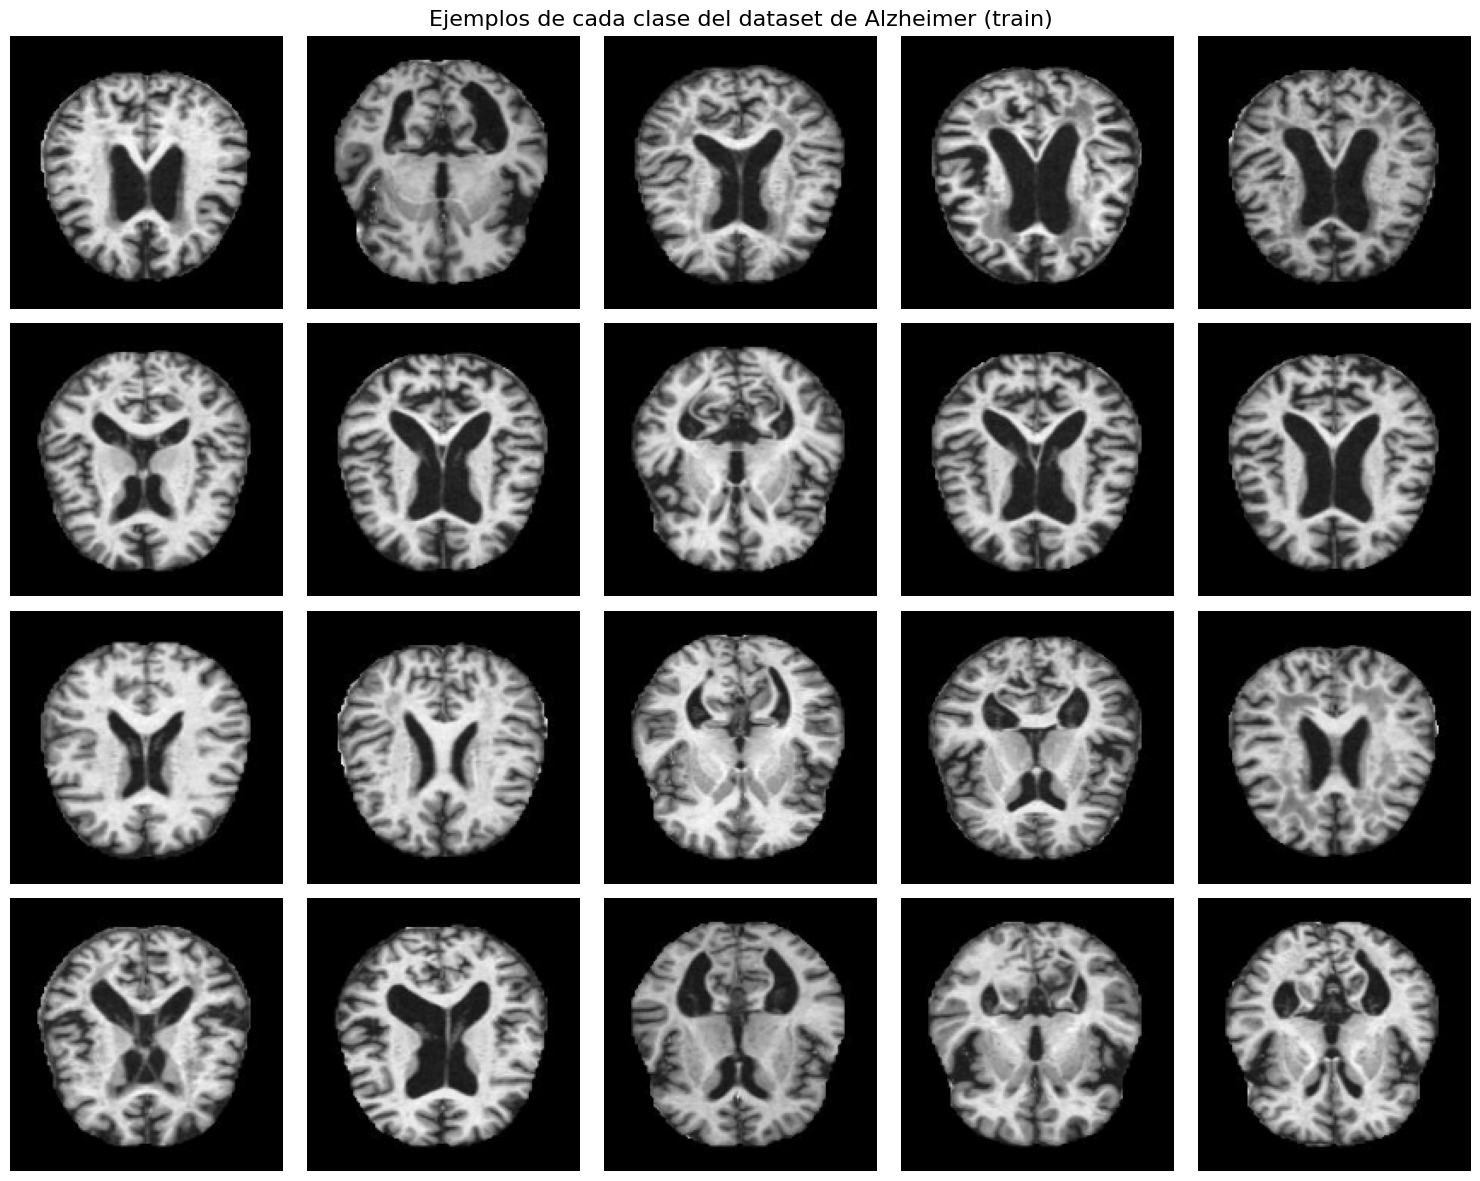

In [4]:
# Número de ejemplos por clase que queremos mostrar
NUM_PER_CLASS = 5

# Diccionario: índice de clase -> lista de imágenes
examples = {i: [] for i in range(NUM_CLASSES)}

# Recorremos el dataset de entrenamiento, des-batcheado
for img, label in train_ds.unbatch():
    # label viene en one-hot, recuperamos el índice de la clase
    class_idx = int(tf.argmax(label).numpy())

    if len(examples[class_idx]) < NUM_PER_CLASS:
        examples[class_idx].append(img.numpy())

    # Si ya tenemos suficientes de todas las clases
    if all(len(v) >= NUM_PER_CLASS for v in examples.values()):
        break

fig, axes = plt.subplots(
    NUM_CLASSES,
    NUM_PER_CLASS,
    figsize=(NUM_PER_CLASS * 3, NUM_CLASSES * 3)
)

fig.suptitle("Ejemplos de cada clase del dataset de Alzheimer (train)", fontsize=16)

for class_idx in range(NUM_CLASSES):
    for j in range(NUM_PER_CLASS):
        ax = axes[class_idx, j] if NUM_CLASSES > 1 else axes[j]
        ax.imshow(examples[class_idx][j])
        ax.axis("off")

        # Solo en la primera columna escribimos el nombre de la clase
        if j == 0:
            ax.set_ylabel(diagnosis_mapping[class_idx], fontsize=12)

plt.tight_layout()
plt.show()

In [5]:
#ViT Head
class ViTHead(layers.Layer):
    def __init__(self, embed_dim=256, num_heads=4, mlp_dim=512, num_transformer_layers=2, dropout_rate=0.1, **kwargs):
        super(ViTHead, self).__init__(**kwargs)
        self.embed_dim =embed_dim
        self.num_heads= num_heads
        self.mlp_dim =mlp_dim
        self.num_transformer_layers =num_transformer_layers
        self.dropout_rate =dropout_rate

    def build(self, input_shape):
        self.num_patches =input_shape[1] * input_shape[2]  # 5x5
        self.feature_dim =input_shape[3]
        self.projection =layers.Dense(self.embed_dim)#proj
        self.cls_token =self.add_weight(#cls token gen
            shape=(1, 1, self.embed_dim),
            initializer="random_normal",
            trainable=True,
            name="cls_token"
        )#pos-embedding
        self.pos_embed = self.add_weight(
            shape=(1, self.num_patches + 1, self.embed_dim),
            initializer="random_normal",
            trainable=True,
            name="pos_embed"
        )
        self.transformer_blocks = []
        for _ in range(self.num_transformer_layers):
            self.transformer_blocks.append([
                layers.LayerNormalization(epsilon=1e-6),
                layers.MultiHeadAttention(#mla
                    num_heads=self.num_heads,
                    key_dim=self.embed_dim // self.num_heads,
                    dropout=self.dropout_rate
                ),
                layers.LayerNormalization(epsilon=1e-6),
                layers.Dense(self.mlp_dim, activation="gelu"),
                layers.Dropout(self.dropout_rate),
                layers.Dense(self.embed_dim)
            ])
        self.layer_norm = layers.LayerNormalization(epsilon=1e-6)

    def call(self, inputs, training=False):
        batch_size =tf.shape(inputs)[0]
        x= tf.reshape(inputs, [batch_size, self.num_patches, self.feature_dim])
        x= self.projection(x)
        cls_tokens = tf.broadcast_to(self.cls_token, [batch_size, 1, self.embed_dim])
        x= tf.concat([cls_tokens, x], axis=1)
        x= x + self.pos_embed

        for norm1, attn, norm2, dense1, drop1, dense2 in self.transformer_blocks:
            x_norm =norm1(x)
            attention_output =attn(x_norm, x_norm, x_norm, training=training)
            x=x+attention_output
            x_norm =norm2(x)
            x_mlp =dense1(x_norm)
            x_mlp =drop1(x_mlp, training=training)
            x_mlp= dense2(x_mlp)
            x = x + x_mlp

        x = self.layer_norm(x)
        return x[:, 0]

In [6]:
# Base-model
base_model=MobileNetV2(
    include_top=False,
    weights="imagenet",
    input_shape=(*IMAGE_SIZE, 3)
)

#90%freeze next improvement:~80%
layer_n =len(base_model.layers)
freeze =int(layer_n * 0.9)
for i, layer in enumerate(base_model.layers):
    layer.trainable = (i >= freeze)

#complete model
inputs =layers.Input(shape=(*IMAGE_SIZE, 3))
x =base_model(inputs, training=False)
vit_out =ViTHead(embed_dim=256,
                 num_heads=4,
                 mlp_dim=512,
                 num_transformer_layers=2,
                 dropout_rate=0.1)(x)

x =layers.Dropout(0.5)(vit_out)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
model = models.Model(inputs=inputs, outputs=outputs)

model.compile(optimizer=optimizers.Adam(1e-4),
              loss="categorical_crossentropy",
              metrics=["accuracy"],
              jit_compile=True)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [7]:
early_stop =callbacks.EarlyStopping(monitor="val_accuracy",
                                    patience=10,
                                    restore_best_weights=True)
checkpoint =callbacks.ModelCheckpoint("alzheimer_mobilenet_phase1.keras",
                                      monitor="val_accuracy",
                                      save_best_only=True)

#Phase 1
print("\nPhase 1: Training with frozen base model")#increase epoch next time
history_phase1 = model.fit( train_ds,
                           validation_data=val_ds,
                           epochs=30,
                           callbacks=[early_stop, checkpoint])



Phase 1: Training with frozen base model
Epoch 1/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 84s 304ms/step - accuracy: 0.4812 - loss: 1.5311 - val_accuracy: 0.4641 - val_loss: 1.1571
Epoch 2/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.6360 - loss: 0.8771 - val_accuracy: 0.3734 - val_loss: 1.9435
Epoch 3/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.8169 - loss: 0.4761 - val_accuracy: 0.3602 - val_loss: 3.3595
Epoch 4/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.9129 - loss: 0.2386 - val_accuracy: 0.4719 - val_loss: 2.5480
Epoch 5/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - accuracy: 0.9253 - loss: 0.2136 - val_accuracy: 0.6453 - val_loss: 1.4621
Epoch 6/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.9536 - loss: 0.1202 - val_accuracy: 0.6430 - val_loss: 1.3333
Epoch 7/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.9701 - loss: 0.0826 - val_accuracy: 0.6305 - val_loss: 1.7013
Epoch 8/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.98

In [8]:
# Phase 2
for layer in base_model.layers[freeze:]:
    layer.trainable = True
model.compile(optimizer=optimizers.Adam(1e-5),
              loss="categorical_crossentropy",
              metrics=["accuracy"],
              jit_compile=True)

print("\nPhase 2: Fine-tuning")
checkpoint_ft = callbacks.ModelCheckpoint("alzheimer_mobilenet_phase2.keras",
                                          monitor="val_loss",
                                          save_best_only=True)
history_phase2 = model.fit( train_ds,
                           validation_data=val_ds,
                           epochs=50,
                           callbacks=[early_stop, checkpoint_ft])


Phase 2: Fine-tuning
Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 52s 206ms/step - accuracy: 0.9968 - loss: 0.0076 - val_accuracy: 0.8062 - val_loss: 0.9292
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - accuracy: 1.0000 - loss: 5.6569e-04 - val_accuracy: 0.8281 - val_loss: 0.8296
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - accuracy: 1.0000 - loss: 3.3246e-04 - val_accuracy: 0.8414 - val_loss: 0.7694
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 1.0000 - loss: 2.4443e-04 - val_accuracy: 0.8523 - val_loss: 0.7084
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - accuracy: 1.0000 - loss: 1.6727e-04 - val_accuracy: 0.8648 - val_loss: 0.6675
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 1.0000 - loss: 2.2587e-04 - val_accuracy: 0.8773 - val_loss: 0.6266
Epoch 7/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 1.0000 - loss: 1.2573e-04 - val_accuracy: 0.8844 - val_loss: 0.5813
Epoch 8/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 

# A. Análisis del pipeline de datos
1. Cambiar IMAGE_SIZE (por ejemplo 128×128 o 224×224) y comparar:
    - tiempo de entrenamiento
    - accuracy


In [9]:
results = []
model_paths = []
image_sizes = [(128, 128), (160, 160), (224, 224)]
histories = []

for size in image_sizes:
    print(f"\nEntrenando modelo con IMAGE_SIZE = {size}")
    start = time.time()

    IMAGE_SIZE = size
    model_path = f"model_alzheimer_{size[0]}x{size[1]}.keras"
    model_paths.append(model_path)
    base_model = MobileNetV2(include_top=False, weights="imagenet", input_shape=(*IMAGE_SIZE, 3))
    layer_n = len(base_model.layers)
    freeze = int(layer_n * 0.9)
    for i, layer in enumerate(base_model.layers):
        layer.trainable = (i >= freeze)

    inputs = layers.Input(shape=(*IMAGE_SIZE, 3))
    x = base_model(inputs, training=False)
    vit_out = ViTHead(embed_dim=256, num_heads=4, mlp_dim=512, num_transformer_layers=2, dropout_rate=0.1)(x)
    x = layers.Dropout(0.5)(vit_out)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    model = models.Model(inputs=inputs, outputs=outputs)

    model.compile(optimizer=optimizers.Adam(1e-4),
                  loss="categorical_crossentropy",
                  metrics=["accuracy"],
                  jit_compile=True)

    # Entrenamiento
    early_stop = callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
        )
    checkpoint =callbacks.ModelCheckpoint(model_path,
                                          monitor="val_accuracy",
                                          save_best_only=True)

    # Redefinir datasets para nuevo tamaño
    def decode_image(file_path, label):
        img = tf.io.read_file(file_path)
        img = tf.image.decode_png(img, channels=3)
        img = tf.image.resize(img, IMAGE_SIZE)
        img = tf.cast(img, tf.float32) / 255.0
        label = tf.one_hot(label, NUM_CLASSES)
        return img, label

    # Redefinir datasets para este tamaño
    train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
    train_ds = train_ds.shuffle(buffer_size=len(train_paths))
    train_ds = train_ds.map(decode_image, num_parallel_calls=tf.data.AUTOTUNE)
    train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
    val_ds = val_ds.map(decode_image, num_parallel_calls=tf.data.AUTOTUNE)
    val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=30,
        callbacks=[early_stop, checkpoint],
        verbose=2
    )

    end = time.time()
    accuracy = history.history['val_accuracy'][-1]
    duration = round(end - start, 2)
    results.append((size, duration, accuracy))
    histories.append((size, history))

# Mostrar resultados
print("\n Resultados por tamaño de imagen:")
for s, t, a in results:
    print(f" {s}: {t} segundos - Accuracy val: {round(a * 100, 2)}%")


Entrenando modelo con IMAGE_SIZE = (128, 128)
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/30
80/80 - 76s - 952ms/step - accuracy: 0.5000 - loss: 1.2915 - val_accuracy: 0.5352 - val_loss: 1.0748
Epoch 2/30
80/80 - 4s - 54ms/step - accuracy: 0.7129 - loss: 0.7155 - val_accuracy: 0.4000 - val_loss: 1.6464
Epoch 3/30
80/80 - 4s - 50ms/step - accuracy: 0.8316 - loss: 0.4363 - val_accuracy: 0.3969 - val_loss: 1.8984
Epoch 4/30
80/80 - 5s - 57ms/step - accuracy: 0.9336 - loss: 0.1782 - val_accuracy: 0.3812 - val_loss: 3.4351
Epoch 5/30
80/80 - 4s - 50ms/step - accuracy: 0.9678 - loss: 0.0971 - val_accuracy: 0.3898 - val_loss: 3.2752
Epoch 6/30
80/80 - 4s - 49ms/step - accuracy: 0.9646 - loss: 0.1029 - val_accuracy: 0.3586 - val_loss: 4.2474

Entrenando modelo con IMAGE_SIZE = (160, 160)
Epoch 1/30
80/80 - 57s - 708ms/step - accuracy: 0.4994 - loss: 1.3943 - val_accuracy: 0.5031 - val_loss: 1.3145
Epoch 2/30
80/80 - 6s - 69ms/step - accuracy: 0.6650 - loss: 0.8319 - val_accuracy:

# D. Visualización y análisis
1. Graficar curvas de:
    - accuracy entrenamiento/validación
    - loss entrenamiento/validación


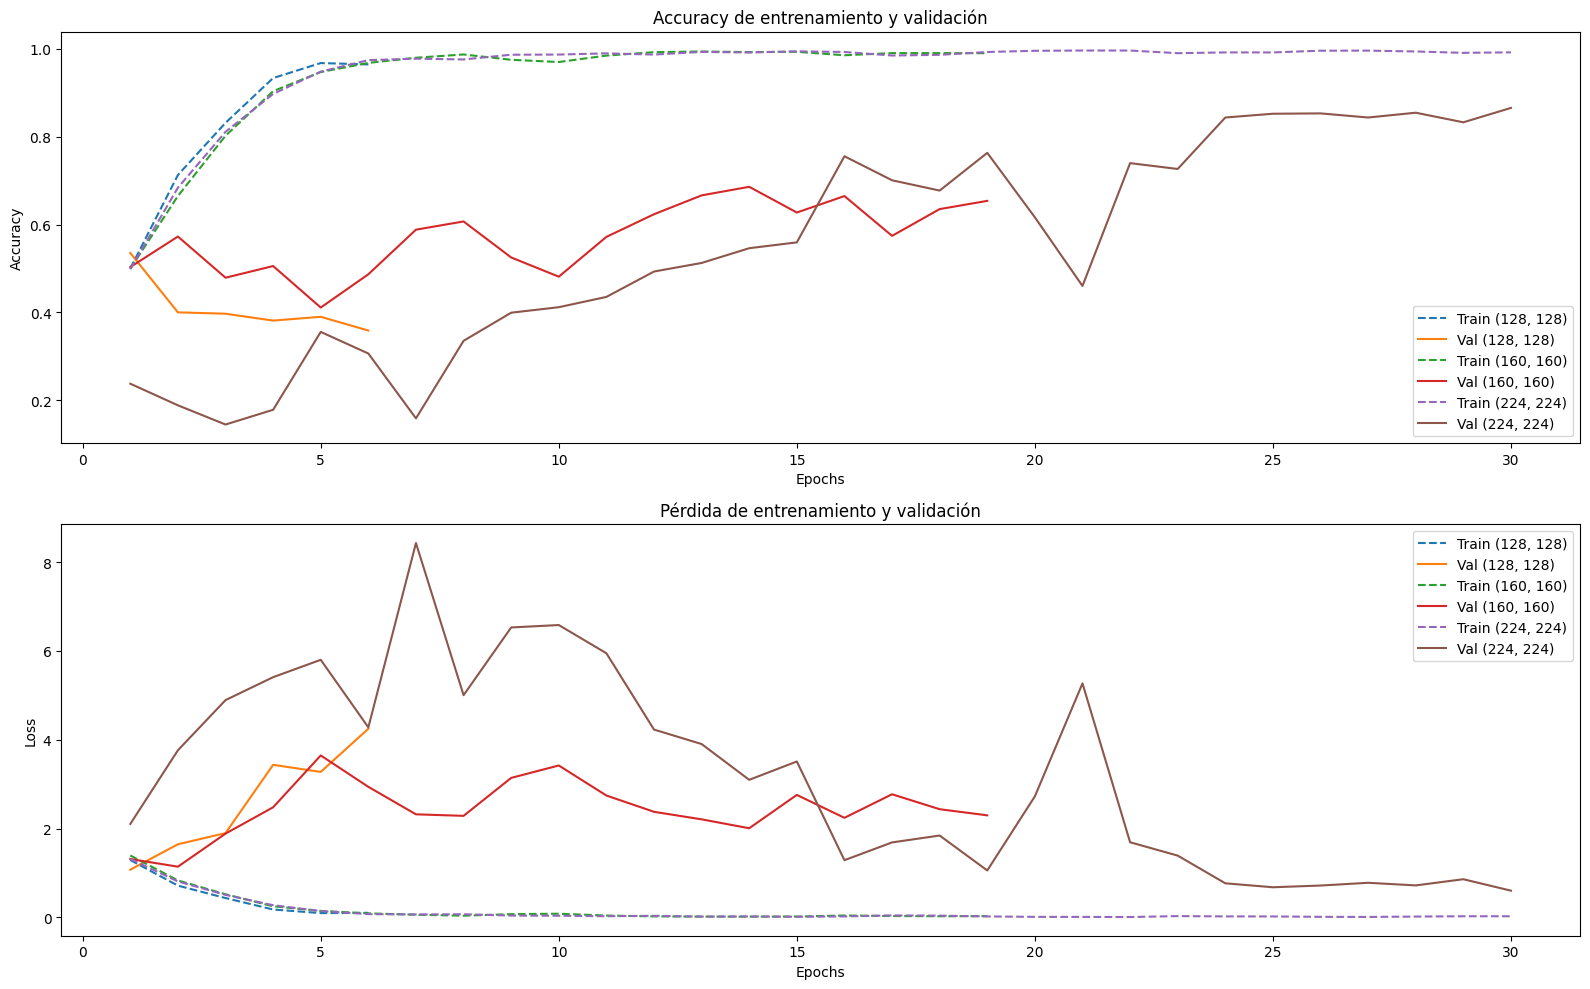

In [10]:
def plot_train_and_val_curves_all_sizes(histories):
    plt.figure(figsize=(16, 10))

    for size, history in histories:
        epochs = range(1, len(history.history['accuracy']) + 1)

        # Accuracy
        plt.subplot(2, 1, 1)
        plt.plot(epochs, history.history['accuracy'], linestyle='--', label=f'Train {size}')
        plt.plot(epochs, history.history['val_accuracy'], label=f'Val {size}')
        plt.xlabel('Epochs')
        plt.ylabel('Accuracy')
        plt.title('Accuracy de entrenamiento y validación')
        plt.legend()

        # Loss
        plt.subplot(2, 1, 2)
        plt.plot(epochs, history.history['loss'], linestyle='--', label=f'Train {size}')
        plt.plot(epochs, history.history['val_loss'], label=f'Val {size}')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.title('Pérdida de entrenamiento y validación')
        plt.legend()

    plt.tight_layout()
    plt.show()

plot_train_and_val_curves_all_sizes(histories)


2.	Crear una matriz de confusión con el modelo final.


Matriz de confusión para modelo con tamaño (128, 128)


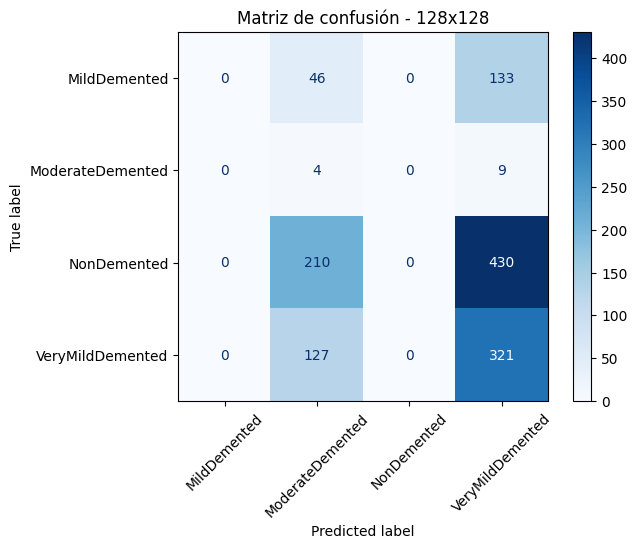


Matriz de confusión para modelo con tamaño (160, 160)


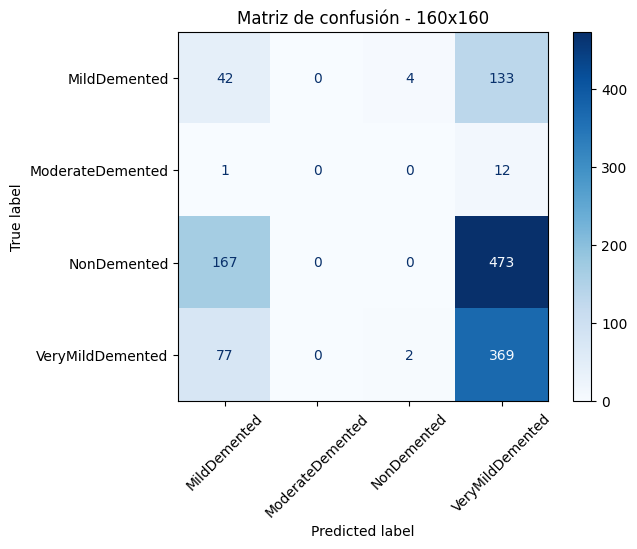


Matriz de confusión para modelo con tamaño (224, 224)


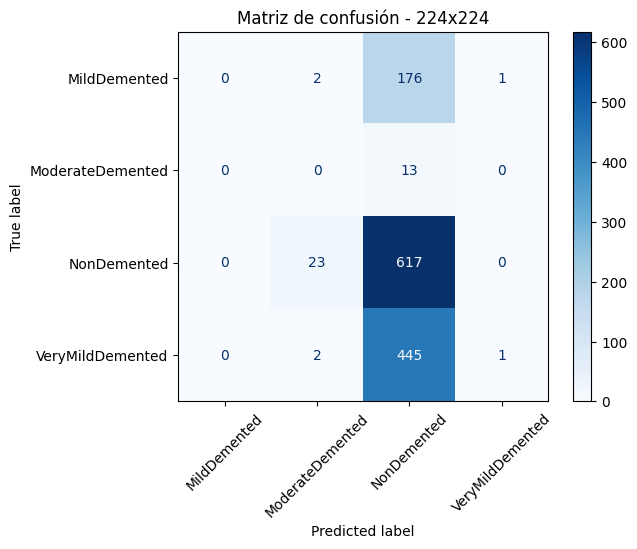

In [11]:
def mostrar_matriz_confusion_por_tamaño(image_sizes, model_paths):
    for size, model_path in zip(image_sizes, model_paths):
        print(f"\nMatriz de confusión para modelo con tamaño {size}")

        IMAGE_SIZE = size

        def decode_image(file_path, label):
            img = tf.io.read_file(file_path)
            img = tf.image.decode_png(img, channels=3)
            img = tf.image.resize(img, IMAGE_SIZE)
            img = tf.cast(img, tf.float32) / 255.0
            label = tf.one_hot(label, NUM_CLASSES)
            return img, label

        # Reconstruir val_ds para ese tamaño
        val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
        val_ds = val_ds.map(decode_image, num_parallel_calls=tf.data.AUTOTUNE)
        val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

        # Cargar el modelo entrenado
        model = tf.keras.models.load_model(model_path, custom_objects={"ViTHead": ViTHead})

        # Obtener predicciones
        y_true, y_pred = [], []
        for images, labels in val_ds:
            preds = model.predict(images, verbose=0)
            y_true.extend(tf.argmax(labels, axis=1).numpy())
            y_pred.extend(tf.argmax(preds, axis=1).numpy())

        # Matriz de confusión
        cm = confusion_matrix(y_true, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(diagnosis_mapping.values()))
        disp.plot(cmap='Blues')
        plt.title(f"Matriz de confusión - {size[0]}x{size[1]}")
        plt.xticks(rotation=45)
        plt.show()

mostrar_matriz_confusion_por_tamaño(image_sizes, model_paths)

In [12]:
# Tabla resumen final de resultados
import pandas as pd

df_resultados = pd.DataFrame(results, columns=["Tamaño", "Tiempo (s)", "Accuracy Val"])
df_resultados["Accuracy Val"] = df_resultados["Accuracy Val"].apply(lambda x: f"{x*100:.2f}%")
display(df_resultados)


,Tamaño,Tiempo (s),Accuracy Val
0,"(128, 128)",98.30,35.86%
1,"(160, 160)",155.32,65.39%
2,"(224, 224)",313.73,86.56%
